<a href="https://colab.research.google.com/github/NsGp-dr/IPREA_GuiaDeEstudioPersonal/blob/main/MapasAGrafosFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **De Mapas a Grafos**
## 📦 Celda 0 – Instalación de librerías

In [1]:
# Instalación única
!pip install -q folium networkx scikit-learn plotly python-louvain geopandas requests

## 📂 Celda 1 – Subir un archivo GeoJSON y leer los puntos

In [ ]:
from google.colab import files
import geopandas as gpd
import pandas as pd
import numpy as np

print("Por favor, sube un archivo GeoJSON con puntos (también vale CSV con lat/lon)...")
uploaded = files.upload()

# Leer el primer archivo subido
filename = next(iter(uploaded))
try:
    gdf = gpd.read_file(filename)
except Exception:
    # Si no es GeoJSON, intentar leer como CSV con columnas 'lat','lon'
    gdf = pd.read_csv(filename)
    if 'lat' in gdf.columns and 'lon' in gdf.columns:
        from shapely.geometry import Point
        gdf['geometry'] = gdf.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
        gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs="EPSG:4326")
    else:
        raise ValueError("El archivo debe tener columnas 'lat'/'lon' o ser GeoJSON válido")

# Asegurar que tenemos lat/lon
if gdf.geometry.geom_type[0] == 'Point':
    gdf['lon'] = gdf.geometry.x
    gdf['lat'] = gdf.geometry.y
else:
    # Si son polígonos, usar centroide
    gdf['lon'] = gdf.geometry.centroid.x
    gdf['lat'] = gdf.geometry.centroid.y

print(f"Se cargaron {len(gdf)} puntos.")
gdf.head()

**Alternativa (si no tienes GeoJSON)**: puedes comentar las líneas de subida y usar el conjunto de ejemplo que aparece en la siguiente celda.

## 🌍 Celda 2 (opcional) – Puntos de ejemplo si no se subió archivo

In [5]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point

# Puntos de ejemplo: Madrid y alrededores (8 localizaciones)
data = {
    "name": ["Sol", "Retiro", "Chamartín", "Casa de Campo", "Argüelles", "Salamanca", "Campamento", "Vallecas"],
    "lat":  [40.4168, 40.4170, 40.4500, 40.4100, 40.4300, 40.4200, 40.4000, 40.3900],
    "lon":  [-3.7038, -3.6830, -3.6830, -3.7300, -3.7100, -3.6900, -3.7500, -3.6400]
}
gdf = gpd.GeoDataFrame(
    data,
    geometry=[Point(lon, lat) for lon, lat in zip(data["lon"], data["lat"])],
    crs="EPSG:4326"
)
print(f"Se cargaron {len(gdf)} puntos de ejemplo.")
gdf[["name", "lat", "lon"]]

Se cargaron 8 puntos de ejemplo.


,name,lat,lon
0,Sol,40.4168,-3.7038
1,Retiro,40.4170,-3.6830
2,Chamartín,40.4500,-3.6830
3,Casa de Campo,40.4100,-3.7300
4,Argüelles,40.4300,-3.7100
5,Salamanca,40.4200,-3.6900
6,Campamento,40.4000,-3.7500
7,Vallecas,40.3900,-3.6400


## 🌤️ Celda 3 – Enriquecimiento con APIs gratuitas (Open‑Meteo)

Añadimos temperatura, viento, humedad, calidad del aire (AQI europeo) y elevación.

In [6]:
import requests
import time

def get_climate(lat, lon):
    """Temperatura actual (°C), viento (km/h), humedad (%)"""
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "current_weather": True,
        "hourly": "relativehumidity_2m",
        "forecast_hours": 1
    }
    try:
        r = requests.get(url, params=params, timeout=10)
        data = r.json()
        cur = data["current_weather"]
        hum = data["hourly"]["relativehumidity_2m"][0]
        return cur["temperature"], cur["windspeed"], hum
    except Exception as e:
        print(f"Error clima en ({lat},{lon}): {e}")
        return None, None, None

def get_air_quality(lat, lon):
    """Índice europeo de calidad del aire (1=muy bueno, 5=muy malo)"""
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {"latitude": lat, "longitude": lon, "current": "european_aqi"}
    try:
        r = requests.get(url, params=params, timeout=10)
        data = r.json()
        return data["current"]["european_aqi"]
    except Exception as e:
        print(f"Error AQI en ({lat},{lon}): {e}")
        return None

def get_elevation(lat, lon):
    """Elevación en metros"""
    url = "https://api.open-meteo.com/v1/elevation"
    params = {"latitude": lat, "longitude": lon}
    try:
        r = requests.get(url, params=params, timeout=10)
        data = r.json()
        return data["elevation"][0]
    except Exception as e:
        print(f"Error elevación en ({lat},{lon}): {e}")
        return None

# Añadir columnas nuevas
for idx, row in gdf.iterrows():
    lat, lon = row["lat"], row["lon"]
    temp, wind, hum = get_climate(lat, lon)
    aqi = get_air_quality(lat, lon)
    elev = get_elevation(lat, lon)
    gdf.at[idx, "temp"] = temp
    gdf.at[idx, "wind"] = wind
    gdf.at[idx, "humidity"] = hum
    gdf.at[idx, "aqi"] = aqi
    gdf.at[idx, "elevation"] = elev
    print(f"  {row['name']:15s} → T:{temp}°C, W:{wind}km/h, H:{hum}%, AQI:{aqi}, Elev:{elev}m")
    time.sleep(0.2)  # pausa para no saturar la API gratuita

# Mostrar resultado
gdf[["name","temp","wind","humidity","aqi","elevation"]]

  Sol             → T:16.0°C, W:10.1km/h, H:59%, AQI:28, Elev:666.0m
  Retiro          → T:16.0°C, W:10.1km/h, H:59%, AQI:27, Elev:672.0m
  Chamartín       → T:15.7°C, W:10.1km/h, H:59%, AQI:27, Elev:707.0m
  Casa de Campo   → T:16.1°C, W:10.5km/h, H:61%, AQI:28, Elev:613.0m
  Argüelles       → T:16.0°C, W:10.1km/h, H:59%, AQI:28, Elev:676.0m
  Salamanca       → T:16.0°C, W:10.1km/h, H:59%, AQI:27, Elev:665.0m
  Campamento      → T:16.4°C, W:11.2km/h, H:53%, AQI:28, Elev:647.0m
  Vallecas        → T:16.5°C, W:11.9km/h, H:53%, AQI:28, Elev:677.0m


,name,temp,wind,humidity,aqi,elevation
0,Sol,16.0,10.1,59.0,28.0,666.0
1,Retiro,16.0,10.1,59.0,27.0,672.0
2,Chamartín,15.7,10.1,59.0,27.0,707.0
3,Casa de Campo,16.1,10.5,61.0,28.0,613.0
4,Argüelles,16.0,10.1,59.0,28.0,676.0
5,Salamanca,16.0,10.1,59.0,27.0,665.0
6,Campamento,16.4,11.2,53.0,28.0,647.0
7,Vallecas,16.5,11.9,53.0,28.0,677.0


## 🕸️ Celda 4 – Construcción del grafo geográfico (vecindad por distancia)

In [7]:
import networkx as nx
import math

def haversine(lat1, lon1, lat2, lon2):
    """Distancia en kilómetros entre dos puntos geográficos"""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

# Coordenadas
coords = list(zip(gdf["lat"], gdf["lon"]))
n = len(coords)

# Calcular la distancia máxima entre cualquier par
dists = [haversine(coords[i][0], coords[i][1], coords[j][0], coords[j][1])
         for i in range(n) for j in range(i+1, n)]
threshold_km = max(dists) * 0.4 if dists else 1.0   # factor 0.4 ajustable

# Crear grafo
G = nx.Graph()
for i, (_, row) in enumerate(gdf.iterrows()):
    G.add_node(i, **row.to_dict())

for i in range(n):
    for j in range(i+1, n):
        d = haversine(coords[i][0], coords[i][1], coords[j][0], coords[j][1])
        if d <= threshold_km:
            G.add_edge(i, j, weight=d)

print(f"Grafo: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas (umbral={threshold_km:.2f} km)")

Grafo: 8 nodos, 13 aristas (umbral=3.75 km)


## 📊 Celda 5 – Métricas del grafo y comunidades (Louvain)

In [10]:
# Aseguramos la instalación de python-louvain (ignora conflictos previos)
!pip install -q python-louvain

import networkx as nx
import pandas as pd

# ---------- Métricas de centralidad ----------
degree = dict(G.degree())
closeness = nx.closeness_centrality(G)
betweenness = nx.betweenness_centrality(G, weight='weight')

try:
    eigenvector = nx.eigenvector_centrality_numpy(G, weight='weight')
except:
    eigenvector = {n: 0 for n in G.nodes()}

metrics = pd.DataFrame({
    "node": list(G.nodes()),
    "name": [G.nodes[i].get("name", str(i)) for i in G.nodes()],
    "degree": [degree[i] for i in G.nodes()],
    "closeness": [round(closeness[i], 4) for i in G.nodes()],
    "betweenness": [round(betweenness[i], 4) for i in G.nodes()],
    "eigenvector": [round(eigenvector[i], 4) for i in G.nodes()]
}).set_index("node")

print("📊 Métricas de centralidad (top 5 por grado):")
display(metrics.sort_values("degree", ascending=False).head())

# ---------- Detección de comunidades ----------
# Intentar con python-louvain; si no, usar greedy_modularity de NetworkX
try:
    import community as community_louvain
    # Verificar que realmente tiene best_partition (a veces el módulo community no es el correcto)
    if not hasattr(community_louvain, 'best_partition'):
        raise ImportError("El módulo 'community' cargado no es python-louvain")

    partition = community_louvain.best_partition(G)
    for node, comm in partition.items():
        G.nodes[node]["community"] = comm
    print(f"\n✅ Comunidades detectadas (Louvain): {len(set(partition.values()))}")

except Exception as e:
    print(f"\n⚠️ Louvain no disponible ({e}). Usando greedy_modularity_communities...")
    from networkx.algorithms.community import greedy_modularity_communities
    communities = greedy_modularity_communities(G)
    partition = {}
    for i, comm in enumerate(communities):
        for node in comm:
            partition[node] = i
    for node, comm in partition.items():
        G.nodes[node]["community"] = comm
    print(f"✅ Comunidades detectadas (greedy modularity): {len(communities)}")

# Mostrar asignación
community_df = pd.DataFrame({
    "Nodo": list(partition.keys()),
    "Nombre": [G.nodes[n].get("name", str(n)) for n in partition.keys()],
    "Comunidad": list(partition.values())
})
print("\nAsignación de comunidades:")
display(community_df.sort_values("Comunidad"))

📊 Métricas de centralidad (top 5 por grado):


,name,degree,closeness,betweenness,eigenvector
node,,,,,
5,Salamanca,5,0.7347,0.0476,0
4,Argüelles,5,0.7347,0.0952,0
0,Sol,4,0.6429,0.0952,0
1,Retiro,4,0.5714,0.0000,0
3,Casa de Campo,4,0.6429,0.2381,0



⚠️ Louvain no disponible (El módulo 'community' cargado no es python-louvain). Usando greedy_modularity_communities...
✅ Comunidades detectadas (greedy modularity): 3

Asignación de comunidades:


,Nodo,Nombre,Comunidad
0,0,Sol,0
1,1,Retiro,0
2,2,Chamartín,0
3,4,Argüelles,0
4,5,Salamanca,0
5,3,Casa de Campo,1
6,6,Campamento,1
7,7,Vallecas,2


##🧬 Celda 6 – Clustering multivariante con DBSCAN

Utilizamos las propiedades descargadas (temperatura, viento, humedad, AQI, elevación) junto con lat/lon para agrupar los puntos.

In [11]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Seleccionar características numéricas (si alguna falta, se rellena con la media)
feature_cols = ["temp", "wind", "humidity", "aqi", "elevation", "lat", "lon"]
df_feat = gdf[feature_cols].copy()
df_feat = df_feat.fillna(df_feat.mean())  # reemplazar NAs de la API

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_feat)

# Aplicar DBSCAN (ajusta eps según la densidad que quieras)
db = DBSCAN(eps=1.5, min_samples=2)
labels = db.fit_predict(X_scaled)

# Guardar en el grafo
for i, label in enumerate(labels):
    G.nodes[i]["cluster_dbscan"] = label

# Resumen de clusters
unique, counts = np.unique(labels, return_counts=True)
for cl, cnt in zip(unique, counts):
    if cl == -1:
        print(f"Ruido: {cnt} puntos")
    else:
        print(f"Cluster {cl}: {cnt} puntos")

Ruido: 4 puntos
Cluster 0: 2 puntos
Cluster 1: 2 puntos


##🗺️ Celda 7 – Mapa 2D interactivo (Folium) con clusters

In [12]:
import folium

# Colores para cada cluster
color_palette = ["red", "blue", "green", "purple", "orange", "darkred", "darkblue", "darkgreen", "cadetblue", "darkpurple", "pink"]

# Centro del mapa
m = folium.Map(location=[gdf["lat"].mean(), gdf["lon"].mean()], zoom_start=12,
               tiles='CartoDB positron')

# Dibujar aristas del grafo
for u, v in G.edges():
    lat_u, lon_u = G.nodes[u]["lat"], G.nodes[u]["lon"]
    lat_v, lon_v = G.nodes[v]["lat"], G.nodes[v]["lon"]
    folium.PolyLine([(lat_u, lon_u), (lat_v, lon_v)], color="gray", weight=1.5, opacity=0.7).add_to(m)

# Dibujar nodos (círculos) coloreados por cluster DBSCAN
for i, (_, row) in enumerate(gdf.iterrows()):
    cluster = G.nodes[i].get("cluster_dbscan", -1)
    color = color_palette[cluster % len(color_palette)] if cluster != -1 else "black"
    popup_text = f"<b>{row['name']}</b><br>Temp: {row['temp']}°C<br>AQI: {row['aqi']}<br>Elev: {row['elevation']}m"
    folium.CircleMarker(
        [row["lat"], row["lon"]],
        radius=7,
        popup=folium.Popup(popup_text, max_width=200),
        color=color,
        fill=True,
        fill_opacity=0.8
    ).add_to(m)

m

##🧊 Celda 8 – Grafo 3D interactivo con Plotly

El eje Z usa la elevación real del terreno. Los colores reflejan los clusters DBSCAN.

In [15]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# ========== 1. Calcular eje Z sintético (PC1) ==========
# Variables que definen el perfil ambiental de cada punto
feat_cols = ["temp", "wind", "humidity", "aqi", "elevation"]
X_env = gdf[feat_cols].fillna(gdf[feat_cols].mean()).values

# PCA: el primer componente principal discriminará los puntos según sus atributos
pca = PCA(n_components=1)
z_pca = pca.fit_transform(X_env).flatten()
# Normalizamos PC1 para que tenga una escala visual similar a las coordenadas (~0.01 grados ~ 1km)
z_range = np.max(z_pca) - np.min(z_pca)
lat_range = gdf["lat"].max() - gdf["lat"].min()
lon_range = gdf["lon"].max() - gdf["lon"].min()
scale_factor = max(lat_range, lon_range) / z_range if z_range > 0 else 1
z_scaled = z_pca * scale_factor

print("Eje Z = primer componente principal de variables ambientales")
print(f"Variabilidad explicada: {pca.explained_variance_ratio_[0]:.1%}")

# ========== 2. Posiciones 3D ==========
pos = {}
for i, (_, row) in enumerate(gdf.iterrows()):
    pos[i] = (row["lon"], row["lat"], z_scaled[i])

# ========== 3. Atributos visuales de los nodos ==========
# Tamaño proporcional al grado del nodo (cambiarlo por 'aqi' si prefieres)
degree_dict = dict(G.degree())
node_sizes = [degree_dict[i] * 3 + 5 for i in G.nodes()]  # escala para que se vean bien

# Color según cluster DBSCAN (paleta cualitativa)
palette = ['#e6194b','#3cb44b','#ffe119','#4363d8','#f58231','#911eb4','#42d4f4','#f032e6']
node_colors = []
for i in G.nodes():
    cl = G.nodes[i].get("cluster_dbscan", -1)
    node_colors.append(palette[cl % len(palette)] if cl != -1 else '#000000')

# Texto mejorado para hover
def hover_info(i):
    nd = G.nodes[i]
    deg = degree_dict.get(i,0)
    cl = nd.get("cluster_dbscan","?")
    com = nd.get("community","?")
    return (f"<b>{nd.get('name', i)}</b><br>"
            f"Temp: {nd['temp']:.1f}°C<br>"
            f"Viento: {nd['wind']:.1f} km/h<br>"
            f"Humedad: {nd['humidity']:.0f}%<br>"
            f"AQI: {nd['aqi']}<br>"
            f"Elev: {nd['elevation']} m<br>"
            f"Grado: {deg}<br>"
            f"Cluster DBSCAN: {cl}<br>"
            f"Comunidad Louvain: {com}")

hover_text = [hover_info(i) for i in G.nodes()]

# ========== 4. Curvatura en las aristas (arcos elevados) ==========
edge_x, edge_y, edge_z = [], [], []
for u, v in G.edges():
    x0, y0, z0 = pos[u]
    x1, y1, z1 = pos[v]
    # Punto medio elevado (curvatura)
    xm, ym = (x0+x1)/2, (y0+y1)/2
    zm = max(z0, z1) + abs(z1-z0)*0.3 + 0.0005  # elevación extra
    # Secuencia de puntos que dibujan una curva suave
    for t in np.linspace(0, 1, num=10):
        x = (1-t)*x0 + t*x1
        y = (1-t)*y0 + t*y1
        z_line = (1-t)*z0 + t*z1
        # Altura parabólica (máxima en el centro)
        z = z_line + 0.3 * zm * (1 - (2*t-1)**2)
        edge_x.append(x)
        edge_y.append(y)
        edge_z.append(z)
    edge_x.append(None)
    edge_y.append(None)
    edge_z.append(None)

trace_edges = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode='lines',
    line=dict(color='rgba(128,128,128,0.5)', width=1.5),
    hoverinfo='none',
    name="Aristas"
)

# ========== 5. Traza de nodos ==========
trace_nodes = go.Scatter3d(
    x=[pos[i][0] for i in G.nodes()],
    y=[pos[i][1] for i in G.nodes()],
    z=[pos[i][2] for i in G.nodes()],
    mode='markers+text',
    text=[G.nodes[i].get("name", i) for i in G.nodes()],
    textposition="top center",
    hovertext=hover_text,
    hoverinfo='text',
    marker=dict(
        size=node_sizes,
        color=node_colors,
        opacity=0.9,
        line=dict(color='black', width=0.5),
        sizemode='diameter',
        sizeref=0.3,   # ajuste fino del tamaño
    ),
    name="Nodos"
)

# ========== 6. Crear figura ==========
fig = go.Figure(data=[trace_edges, trace_nodes])

# Mejorar el diseño
fig.update_layout(
    scene=dict(
        xaxis_title='Longitud',
        yaxis_title='Latitud',
        zaxis_title='Perfil ambiental (PC1)',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.3),  # achatamos Z para no aplastar el mapa
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))  # perspectiva inicial
    ),
    margin=dict(l=0, r=0, b=0, t=30),
    title="Grafo 3D: mapa geográfico elevado por similitud ambiental<br><sup>Color = cluster DBSCAN | Tamaño = grado del nodo | Curvas = conexiones</sup>",
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)
fig.show()

Eje Z = primer componente principal de variables ambientales
Variabilidad explicada: 98.7%


## 📈 Celda 9 (extra) – Análisis de componentes principales (PCA)

Para visualizar cómo se relacionan los puntos en el espacio de atributos.

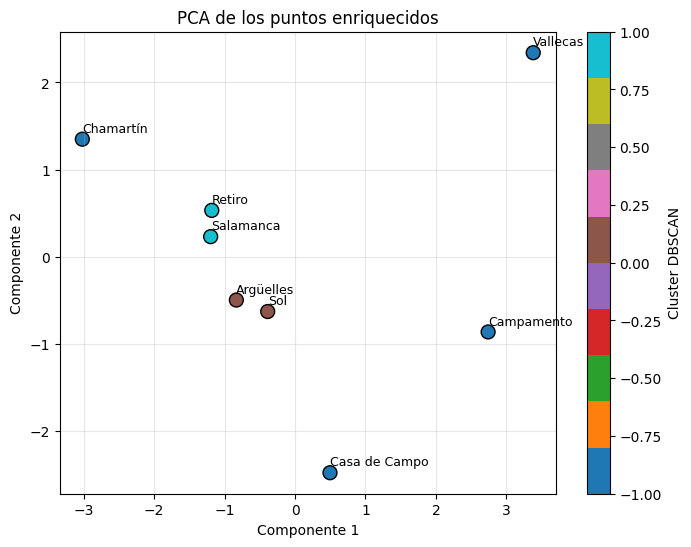

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', s=100, edgecolor='k')
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.title("PCA de los puntos enriquecidos")
plt.colorbar(scatter, label="Cluster DBSCAN")
for i, txt in enumerate(gdf["name"]):
    plt.annotate(txt, (X_pca[i,0], X_pca[i,1]), fontsize=9, textcoords="offset points", xytext=(0,5))
plt.grid(alpha=0.3)
plt.show()